# Super-resolution demo (scale x3)
Загружает обученную модель, прогоняет одну картинку: слева — LR (пикселями), справа — результат модели.

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms as T
import sys, os

sys.path.append(str(Path("../").resolve()))

from src.model import build_model
from src.utils import load_checkpoint

In [2]:
# Paths
ckpt_path = Path('../checkpoints/sr_unet_x3.pt')
image_path = Path('../data/sr/test_hr/0806.png')
scale = 3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


In [3]:
class Cfg: ...
config = Cfg()
config.model = Cfg(); config.model.in_channels=3; config.model.out_channels=3; config.model.base_channels=64; config.model.bilinear=True
model = build_model(config).to(device).eval()
state = load_checkpoint(ckpt_path, map_location=device)
model.load_state_dict(state['model_state_dict'])

<All keys matched successfully>

In [4]:
# Load image
hr = Image.open(image_path).convert('RGB')
# Make LR by downscaling
lr_small = hr.resize((hr.width // scale, hr.height // scale), Image.BICUBIC)
# Pixelated view for visualization (nearest upsample)
lr_pix = lr_small.resize(hr.size, Image.NEAREST)
# Model input: bicubic upsample back to HR size
lr_up = lr_small.resize(hr.size, Image.BICUBIC)

In [6]:
to_tensor = T.ToTensor()
lr_tensor = to_tensor(lr_up).unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(lr_tensor).clamp(0, 1)

pred_img = T.ToPILImage()(pred[0].cpu())

In [33]:
pred.size(), hr.size, lr_small.size

(torch.Size([1, 3, 1356, 2040]), (2040, 1356), (680, 452))

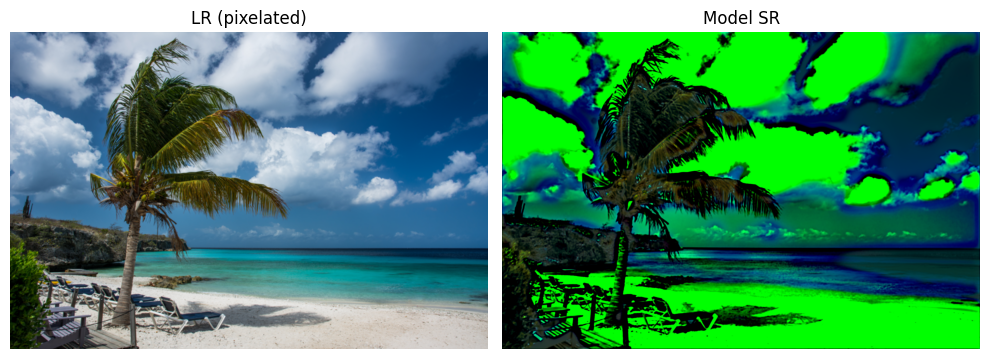

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lr_pix); axes[0].set_title('LR (pixelated)'); axes[0].axis('off')
axes[1].imshow(pred_img); axes[1].set_title('Model SR'); axes[1].axis('off')
plt.tight_layout()
plt.show()

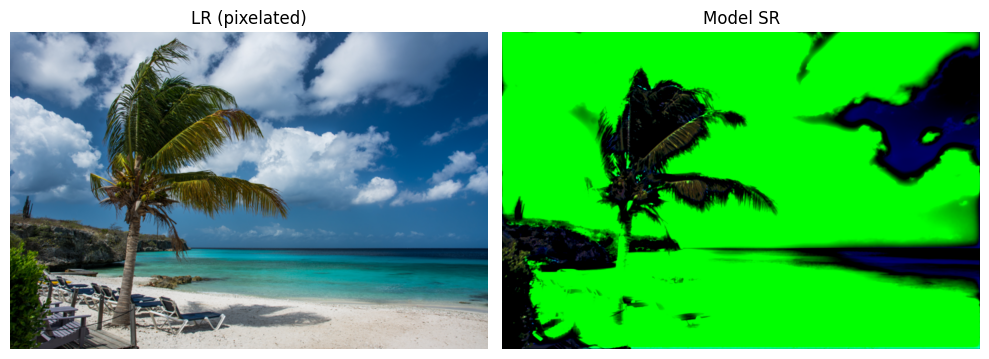

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lr_pix); axes[0].set_title('LR (pixelated)'); axes[0].axis('off')
axes[1].imshow(pred_img); axes[1].set_title('Model SR'); axes[1].axis('off')
plt.tight_layout()
plt.show()

PSNR: 10.57 dB, SSIM: 0.5031


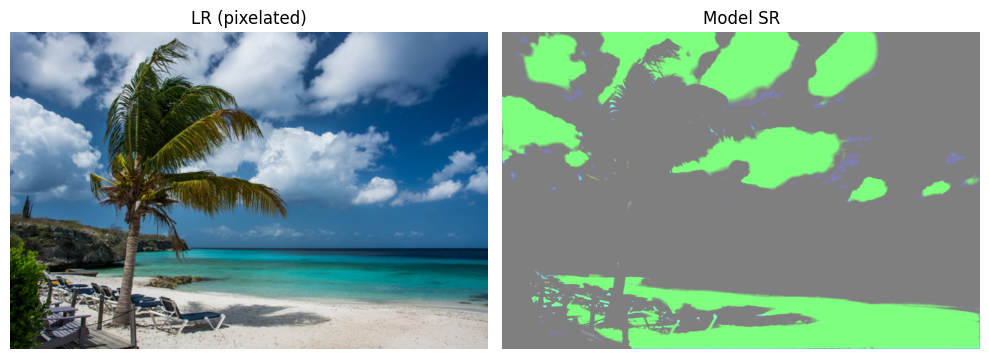

In [8]:
from src.metrics import PSNRMetric, SSIMMetric

mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]
normalize = T.Normalize(mean, std)
inv_normalize = T.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std],
)

# Load HR image
hr = Image.open(image_path).convert('RGB')
# Build LR
lr_small = hr.resize((hr.width // scale, hr.height // scale), Image.BICUBIC)
# Pixelated LR for display only
lr_pix = lr_small.resize(hr.size, Image.NEAREST)
# Model input: bicubic upsample back to HR size
lr_up = lr_small.resize(hr.size, Image.BICUBIC)

# To tensor + normalize
to_tensor = T.ToTensor()
lr_tensor = normalize(to_tensor(lr_up)).unsqueeze(0).to(device)
hr_tensor = normalize(to_tensor(hr)).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(lr_tensor).clamp(0, 1)

# Denormalize for visualization
pred_img = T.ToPILImage()(inv_normalize(pred[0].cpu()).clamp(0, 1))

# Metrics on original scale (using normalized tensors)
psnr = PSNRMetric()(pred[0].cpu(), hr_tensor[0].cpu())
ssim = SSIMMetric()(pred[0].cpu(), hr_tensor[0].cpu())
print(f"PSNR: {psnr:.2f} dB, SSIM: {ssim:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lr_pix); axes[0].set_title('LR (pixelated)'); axes[0].axis('off')
axes[1].imshow(pred_img); axes[1].set_title('Model SR'); axes[1].axis('off')
plt.tight_layout()
plt.show()
